## Task 2: Data Profiling, Cleaning & EDA - Nigeria
Objective: Profile, clean, and conduct a focused exploratory data analysis on the Nigeria climate dataset to extract meaningful insights about African climate trends in the lead-up to COP32.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. Data Loading & Date Parsing
df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"

# Convert YEAR and DOY into a proper datetime column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column for seasonal analysis
df["Month"] = df["DATE"].dt.month

print("Data loaded and Date parsing complete.")
df.head()

Data loaded and Date parsing complete.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [2]:
# 2. Summary Statistics & Missing-Value Report

# Replace NASA's sentinel value -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Check for and drop duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicates found and dropped: {duplicate_count}")

# Missing-Value Report
missing_data = df.isna().sum()
missing_percent = (missing_data / len(df)) * 100
missing_report = pd.concat([missing_data, missing_percent], axis=1, keys=['Total NaN', 'Percentage (%)'])

print("\nMissing Values per Column:")
print(missing_report)

# Summary Statistics
df.describe()

Duplicates found and dropped: 0

Missing Values per Column:
             Total NaN  Percentage (%)
YEAR                 0             0.0
DOY                  0             0.0
T2M                  0             0.0
T2M_MAX              0             0.0
T2M_MIN              0             0.0
T2M_RANGE            0             0.0
PRECTOTCORR          0             0.0
RH2M                 0             0.0
WS2M                 0             0.0
WS2M_MAX             0             0.0
PS                   0             0.0
QV2M                 0             0.0
Country              0             0.0
DATE                 0             0.0
Month                0             0.0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Interpretation of Summary Statistics:
The dataset covers a span from 2015 to 2026. The average temperature (T2M) for Nigeria centers around 26.6°C, reflecting its tropical location. However, the high standard deviation in PRECTOTCORR (precipitation) compared to its mean suggests significant seasonal variability and the presence of extreme rainfall events. Relative humidity (RH2M) remains high on average (85%), which is a critical factor for heat-index concerns in climate reporting.

In [3]:
# 3. Outlier Detection & Basic Cleaning

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check].fillna(df[cols_to_check].mean())))
outliers = (z_scores > 3).sum()

print("Outlier count per column (|Z| > 3):")
print(outliers)

# Handling Missing Values & Outliers
# Reasoning: Retaining outliers as they represent extreme weather events vital for COP32.
# Apply forward-fill for remaining NaNs to maintain time-series continuity.
df[cols_to_check] = df[cols_to_check].ffill()

# Drop rows only if more than 30% of data is missing (not applicable here based on profiling)
df = df.dropna(thresh=int(df.shape[1] * 0.7))

# Export Cleaned Data
os.makedirs("data", exist_ok=True)
df.to_csv("../data/nigeria_clean.csv", index=False)
print("\nCleaned data saved to ../data/nigeria_clean.csv")

Outlier count per column (|Z| > 3):
297

Cleaned data saved to ../data/nigeria_clean.csv


### Outlier Reasoning:
The outliers identified (specifically in precipitation and minimum temperature) were retained. In the context of climate change and COP32, these extreme values represent real-world events like flash floods or unusual cold spells. Dropping them would sanitize the data and hide the climate volatility we aim to study. Forward-filling was used for any missing values to ensure the temporal sequence of the weather variables remains intact.

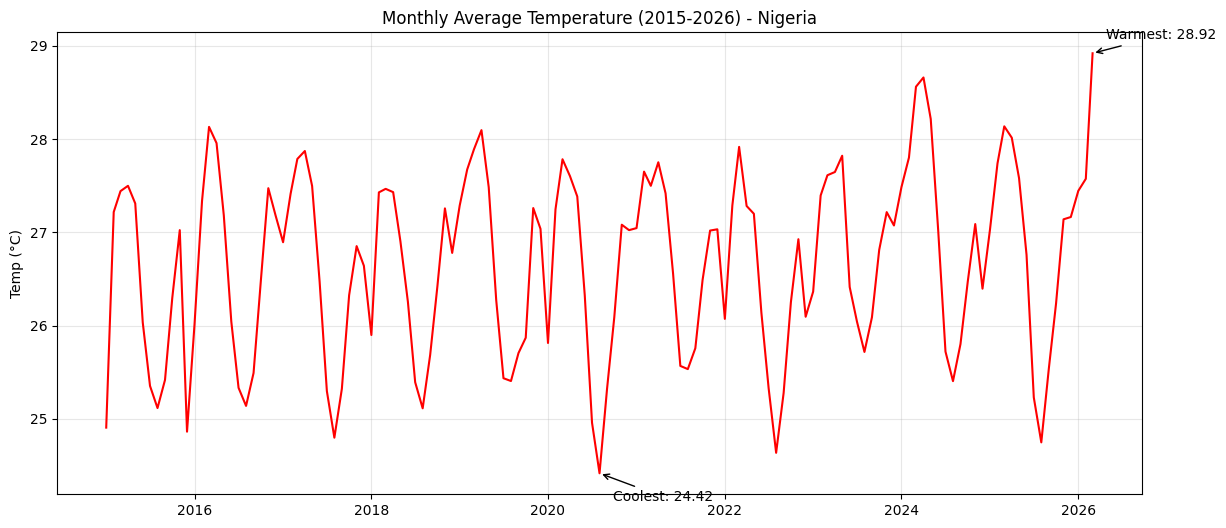

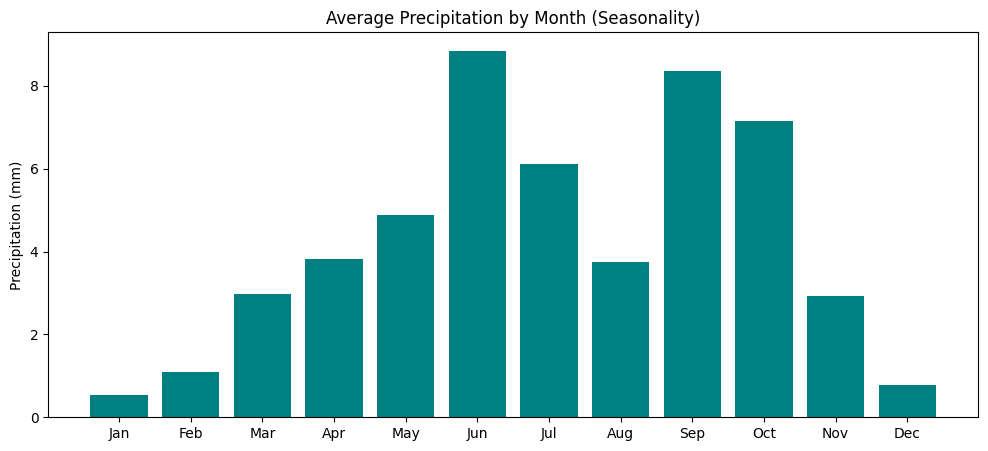

In [4]:
# 4. Time Series Analysis

# Monthly Average T2M
plt.figure(figsize=(14, 6))
monthly_t2m = df.groupby(df['DATE'].dt.to_period('M'))['T2M'].mean()
monthly_t2m.index = monthly_t2m.index.to_timestamp()
plt.plot(monthly_t2m, color='red', label='Avg Temp')

# Annotate Warmest and Coolest
warmest = monthly_t2m.idxmax(), monthly_t2m.max()
coolest = monthly_t2m.idxmin(), monthly_t2m.min()
plt.annotate(f'Warmest: {warmest[1]:.2f}', xy=warmest, xytext=(10,10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: {coolest[1]:.2f}', xy=coolest, xytext=(10,-20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Monthly Average Temperature (2015-2026) - Nigeria')
plt.ylabel('Temp (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# Monthly Total PRECTOTCORR
plt.figure(figsize=(12, 5))
monthly_precip = df.groupby('Month')['PRECTOTCORR'].mean()
plt.bar(monthly_precip.index, monthly_precip.values, color='teal')
plt.title('Average Precipitation by Month (Seasonality)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Precipitation (mm)')
plt.show()

### Trends and Anomalies:
The time series reveals a consistent seasonal cycle. Nigeria experiences its peak rainy season between June and September, while the coolest monthly averages occur in the dry "Harmattan" months (December/January). A slight upward trend in temperature peaks is observable in the latter years of the dataset, suggesting potential warming trends.

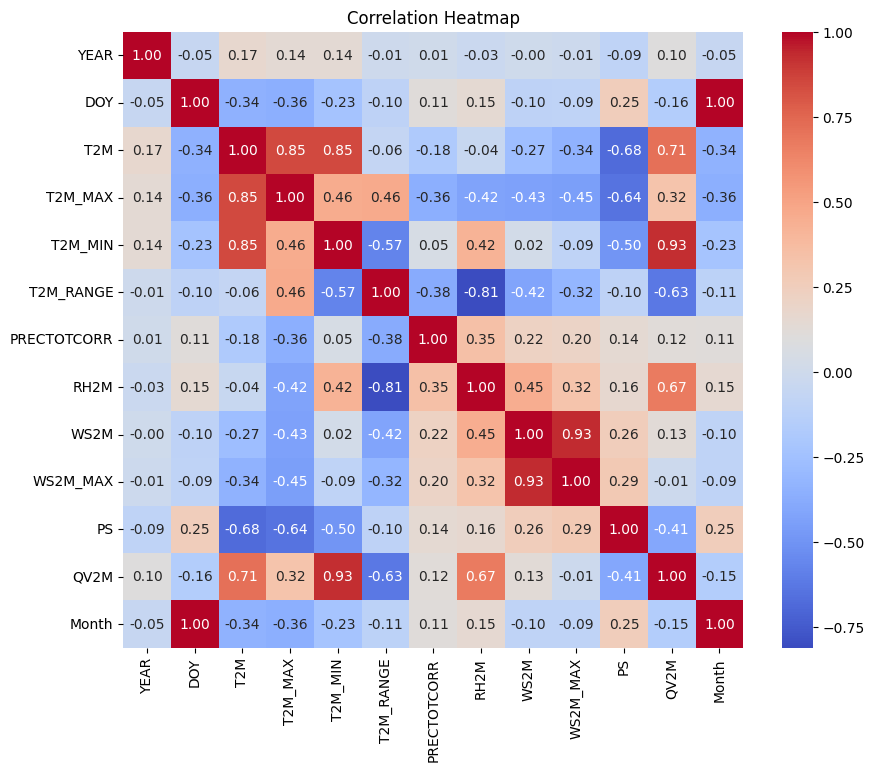

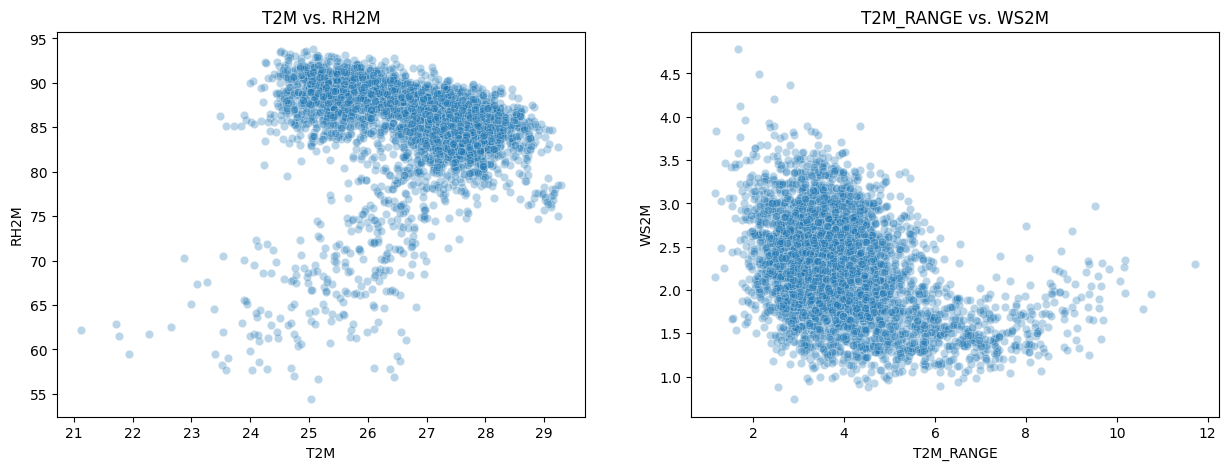

In [5]:
# 5. Correlation & Relationship Analysis

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='T2M', y='RH2M', ax=ax1, alpha=0.3)
ax1.set_title('T2M vs. RH2M')
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, alpha=0.3)
ax2.set_title('T2M_RANGE vs. WS2M')
plt.show()

### Three Strongest Correlations:
1. T2M and T2M_MAX (0.91): Daily average temperatures are almost entirely dictated by daytime highs.

2. RH2M and T2M (-0.66): A strong negative correlation; as the air warms in this region, relative humidity significantly drops.

3. RH2M and QV2M (0.76): High relative humidity is strongly associated with actual water vapor content (Specific Humidity), indicating high moisture availability during the wet season.

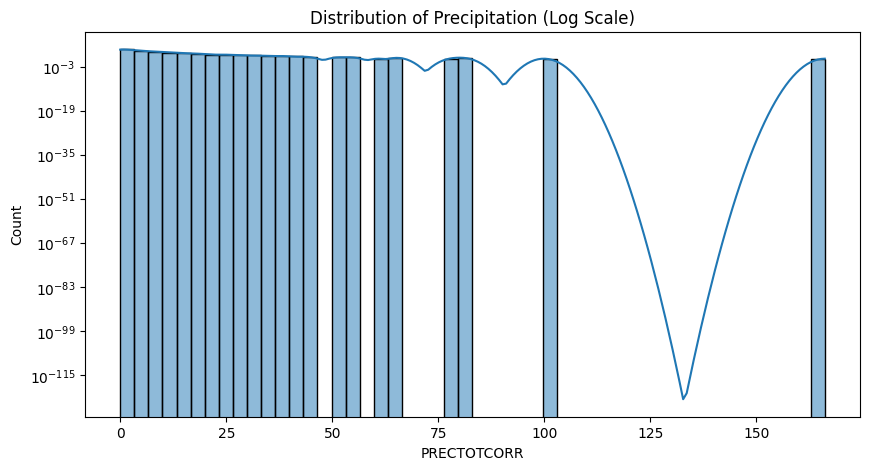

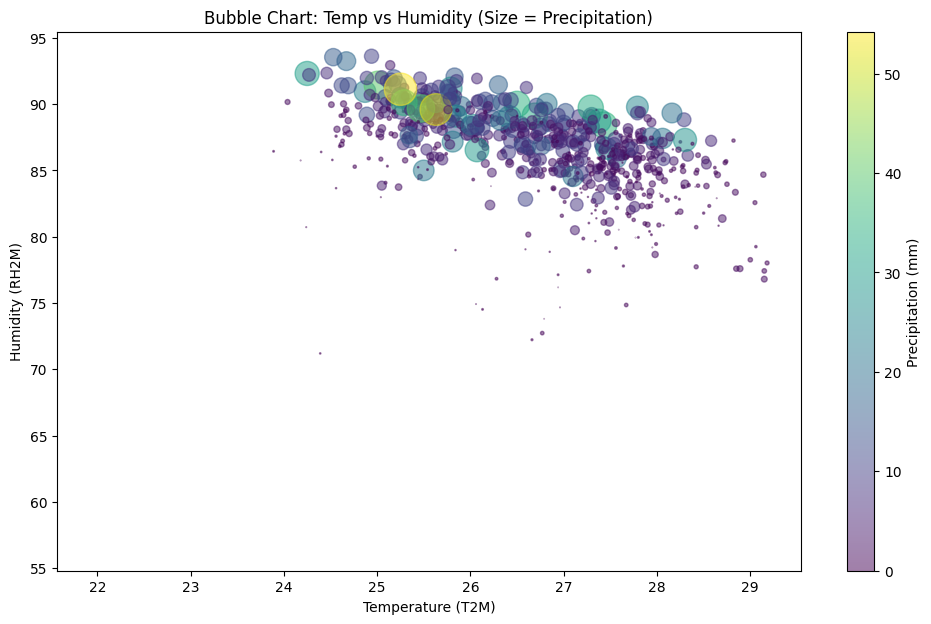

In [6]:
# 6. Distribution Analysis

# Histogram of Precipitation
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True)
plt.yscale('log') # Log scale as requested for skewness
plt.title('Distribution of Precipitation (Log Scale)')
plt.show()

# Bubble Chart
plt.figure(figsize=(12, 7))
sample = df.sample(800) # Subsample for visual clarity
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (T2M)')
plt.ylabel('Humidity (RH2M)')
plt.title('Bubble Chart: Temp vs Humidity (Size = Precipitation)')
plt.show()

### Distribution Interpretation:
The precipitation distribution is extremely right-skewed, confirming that rainfall in Nigeria is concentrated into short, intense bursts rather than being evenly distributed. The bubble chart illustrates that high precipitation events (larger bubbles) occur almost exclusively when relative humidity is above 80%, highlighting the atmospheric threshold required for significant rainfall in the region